# FinTech Innovations: Automated Loan Approval Risk Model

## Overview

**Bottom Line Up Front:** A regularized logistic regression model, trained on 23 application-time features and validated with 5 fold stratified cross validation, predicts loan approval decisions with **ROC-AUC = 0.98** and **F1 = 0.83** on held out test data, matching or slightly beating a tuned Random Forest while remaining fully interpretable. Applied to FinTech Innovations' manual underwriting queue, the model would let staff triage the 20,000-application backlog in seconds instead of days, flag the smaller number of borderline cases that genuinely need a human underwriter, and using a simple cost-of-error estimate built into this analysis, cut the dollar cost of approval mistakes by roughly **75% relative to a "deny everyone" policy** and by even more relative to "approve everyone." The single strongest predictor of approval is a straightforward affordability signal, followed by loan size and applicant net worth. We recommend deploying the logistic regression model as a decision-support tool, with a human in the loop review for applications where the model's predicted probability falls in a borderline range, and a fairness audit of the missing-data patterns discovered during EDA before go live.

## Business Understanding

**Current process and its limitations.** FinTech Innovations currently approves or denies personal loans through manual underwriting: a loan officer reviews each applicant's income, credit history, debts, and assets against internal guidelines and makes a judgment call. This is slow , inconsistent, hard to audit, and doesn't scale.

**Stakeholders and their needs.**
- **Applicants** want a fast, fair, and explainable decision especially if denied, since U.S. lending law requires lenders to be able to state specific reasons for an adverse action.
- **Risk team** wants a tool that flags obviously approve and obviously deny cases automatically and routes only genuinely ambiguous files to a human, while keeping default risk in check.
- **Legal** needs a model whose decision logic can be explained and defended, and that doesn't encode illegal proxies for protected characteristics.
- **Finance** care about the bottom line: loans approved that default cost money; creditworthy applicants who are wrongly turned away cost the company lost interest income and, over time, customer trust.

**Implications of different types of model errors.** This is a binary decision, so there are two ways to be wrong:
- **False Positive**: the model approves an applicant who should have been denied. This risks loan losses if the applicant defaults (principal at risk, collections cost, provisioning).
- **False Negative** : the model denies an applicant who should have been approved. This is a pure opportunity cost if it happens disproportionately to some group.

Because these two error types have very different (and very asymmetric) dollar costs, no single accuracy-style number tells the whole story.
**Classification vs. regression.** FinTech's actual business decision is binary, so we frame this as a **classification** problem. The dataset also contains a continuous `RiskScore`, which looks like it could support a regression framing. We deliberately do **not** use `RiskScore` (or `InterestRate`, `BaseInterestRate`, `MonthlyLoanPayment`, `TotalDebtToIncomeRatio`) as a *predictor*, because EDA below shows they are almost certainly set by the lender's own underwriting process *after* (or as part of) the approval decision. Predicting `LoanApproved` directly from information available *at application time* is both the more faithful modeling choice and the one that maps directly onto the real business decision.

## Modeling Goals and Success Criteria

We use **two primary metrics**, chosen for different reasons, plus one metric we designed specifically for this business:

1. **ROC-AUC** : threshold-independent measure of how well the model ranks approvable applicants above non-approvable ones. Useful because the bank may want to move the approval threshold up or down over time without retraining, and ROC-AUC tells us the model is good across all thresholds, not just one.
2. **F1-score (positive class = Approved)** : the target class is imbalanced (24% approved / 76% denied in this data), so plain accuracy would be misleading. F1 balances precision (don't approve too many bad risks) and recall (don't deny too many good applicants) at the operating threshold we actually plan to use.
3. **Custom metric — expected dollar cost of misclassification.** We estimate a typical dollar profit from a correctly-approved loan (interest income over its term) and a typical dollar loss from a wrongly-approved loan (assumed partial loss of principal on default), then compute `cost = (#false negatives × profit_per_good_loan) + (#false positives × loss_per_bad_loan)`. This turns two abstract error rates into one number executives actually care about, and lets us directly compare the model against "deny everyone" / "approve everyone" baselines in dollar terms.

**Baseline / success targets:** a model is only worth deploying if it clearly beats (a) the majority-class baseline (deny everyone has 76% accuracy, but $0 revenue and an F1 of 0 for the approved class) and (b) a plain logistic regression with default settings. We treat ROC AUC greater than or equal to 0.90 and a meaningfully lower total dollar cost than either naive policy as our bar for a usable model.

## Data Understanding

### Exploratory Data Analysis Plan
We will look at: (1) basic shape/types/missingness, (2) the target's class balance, (3) distributions of the numeric features and how they differ by approval outcome, (4) categorical feature breakdowns, (5) a correlation view across numeric features (including the post decision fields, to justify excluding them), and (6) specific data quality issues worth flagging before modeling.

In [5]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer)

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42


In [ ]:
import pandas as pd

# Load data
df = pd.read_csv(r'C:\RYAN\moringa DS\summative labs\financial_loan_risk\financial_loan_data.csv')

# AnnualIncome was read in as text (e.g. "$39,948.00") - clean it to a float like the other income column
df['AnnualIncome'] = df['AnnualIncome'].replace(r'[\$,]', '', regex=True).astype(float)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 20,000 rows x 35 columns


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,39948.0,617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,39709.0,628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,40724.0,570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,69084.0,545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,103264.0,594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  float64
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  str    
 4   EducationLevel              19099 non-null  str    
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  str    
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  str    
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 non-null

In [4]:
# Missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({'missing_count': missing, 'missing_pct': (missing/len(df)*100).round(2)})


,missing_count,missing_pct
MaritalStatus,1331,6.65
EducationLevel,901,4.50
SavingsAccountBalance,572,2.86


Three columns have missing values: `EducationLevel`, `MaritalStatus`, and `SavingsAccountBalance`. 

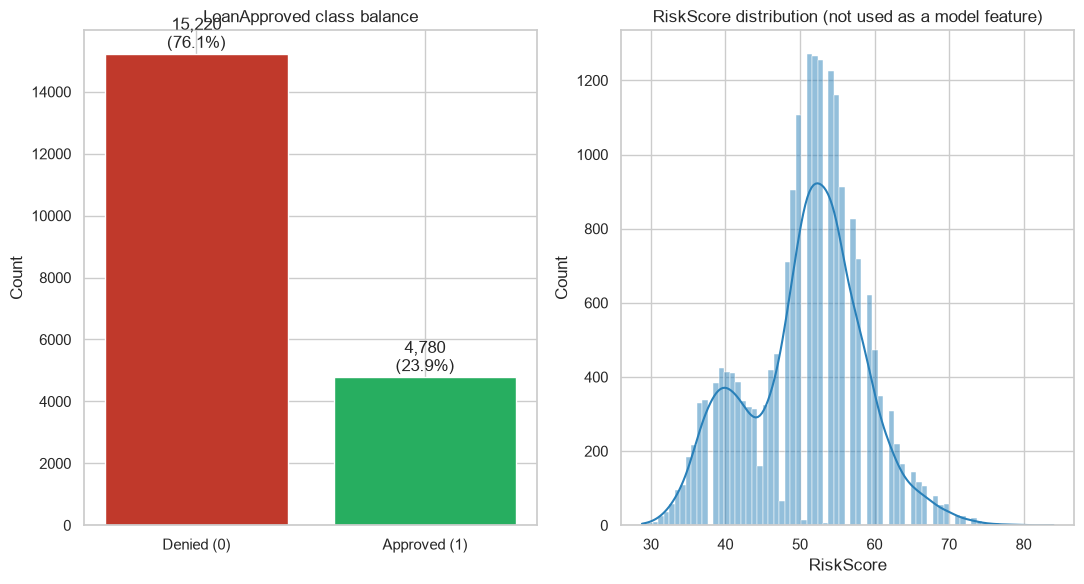

LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


In [7]:
# Target balance
fig, ax = plt.subplots(1, 2, figsize=(11, 6))
counts = df['LoanApproved'].value_counts().sort_index()
ax[0].bar(['Denied (0)', 'Approved (1)'], counts.values, color=['#c0392b', '#27ae60'])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center')
ax[0].set_title('LoanApproved class balance')
ax[0].set_ylabel('Count')

sns.histplot(df['RiskScore'], kde=True, ax=ax[1], color='#2980b9')
ax[1].set_title('RiskScore distribution (not used as a model feature)')
plt.tight_layout()
plt.show()

print(df['LoanApproved'].value_counts(normalize=True).round(3))


**Class imbalance:** only 24% of applications are approved. This confirms we should not rely on plain accuracy and should consider `class_weight='balanced'` during modeling.

29 numeric columns:
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']


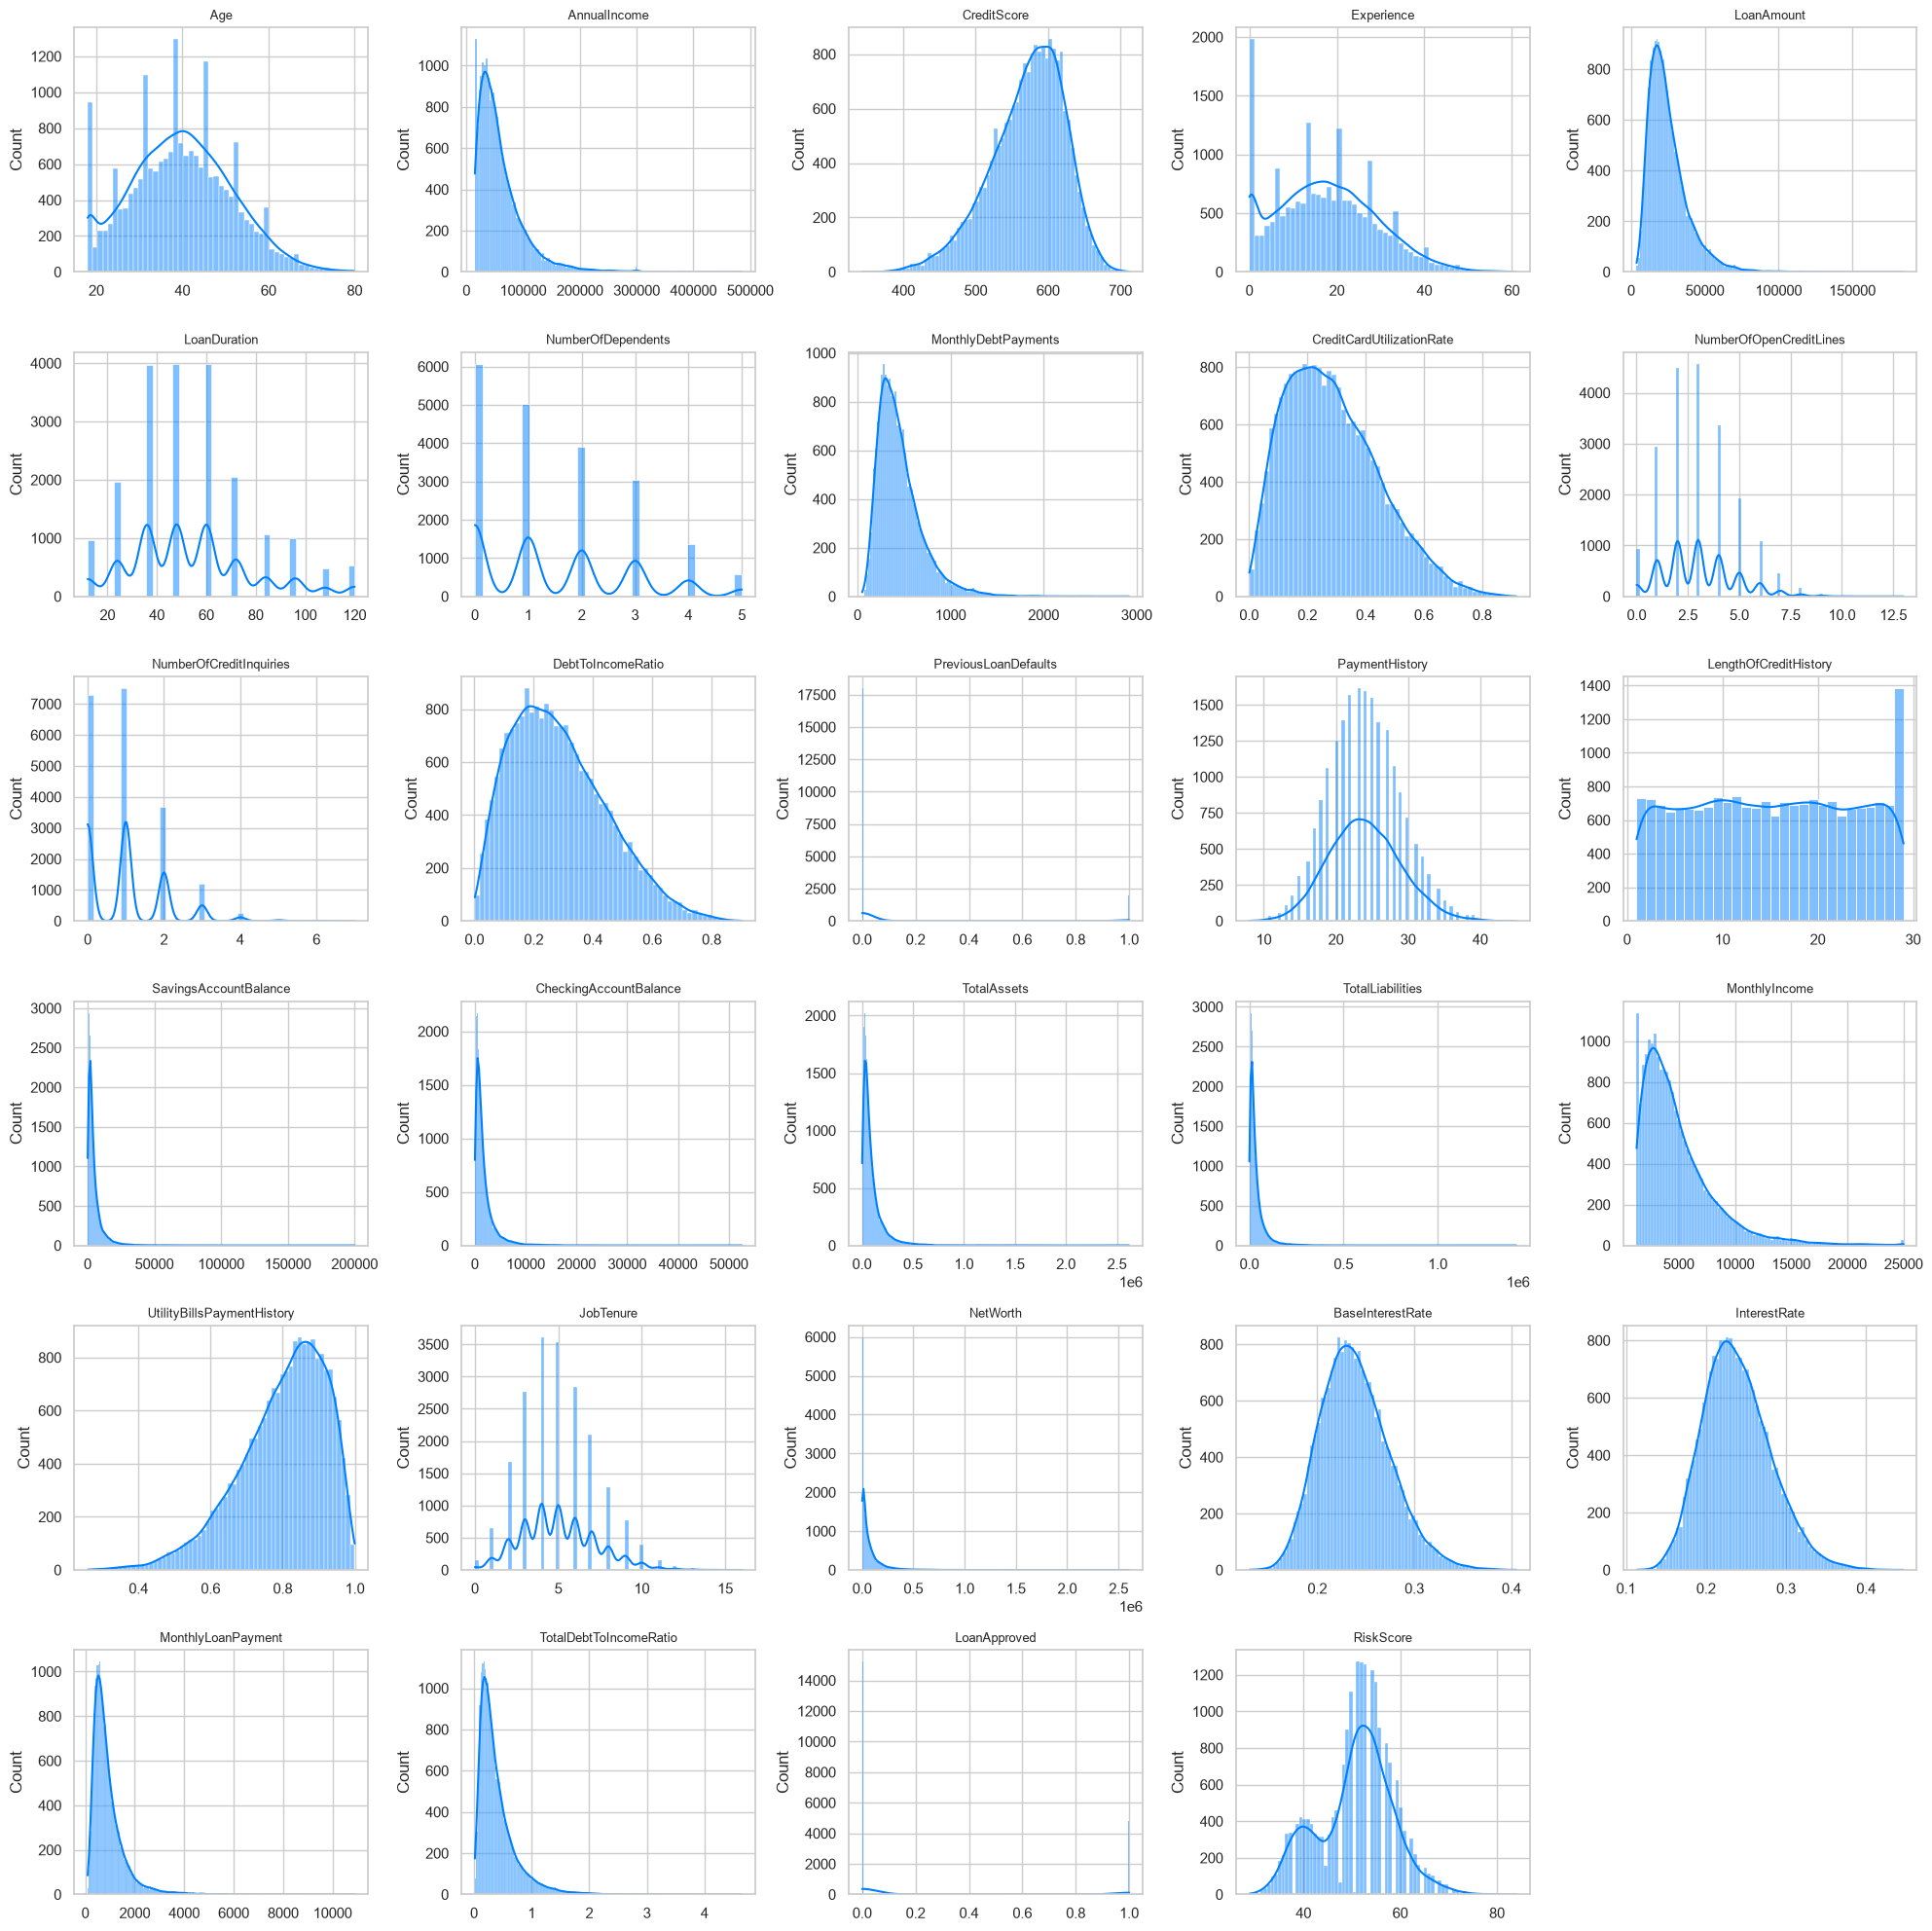

In [8]:
# Numeric feature distributions
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"{len(numeric_cols)} numeric columns:\n{numeric_cols}")

fig, axes = plt.subplots(6, 5, figsize=(20, 20))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], ax=ax, kde=True, color="#0080ff")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
for ax in axes.flatten()[len(numeric_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


Most numeric features are reasonably well behaved (roughly bell-shaped or mildly skewed). A handful `SavingsAccountBalance`, `CheckingAccountBalance`, `TotalAssets`, `TotalLiabilities`, `NetWorth`, `LoanAmount` are right-skewed, as is typical for dollar-amount financial data with a long tail of wealthier applicants.

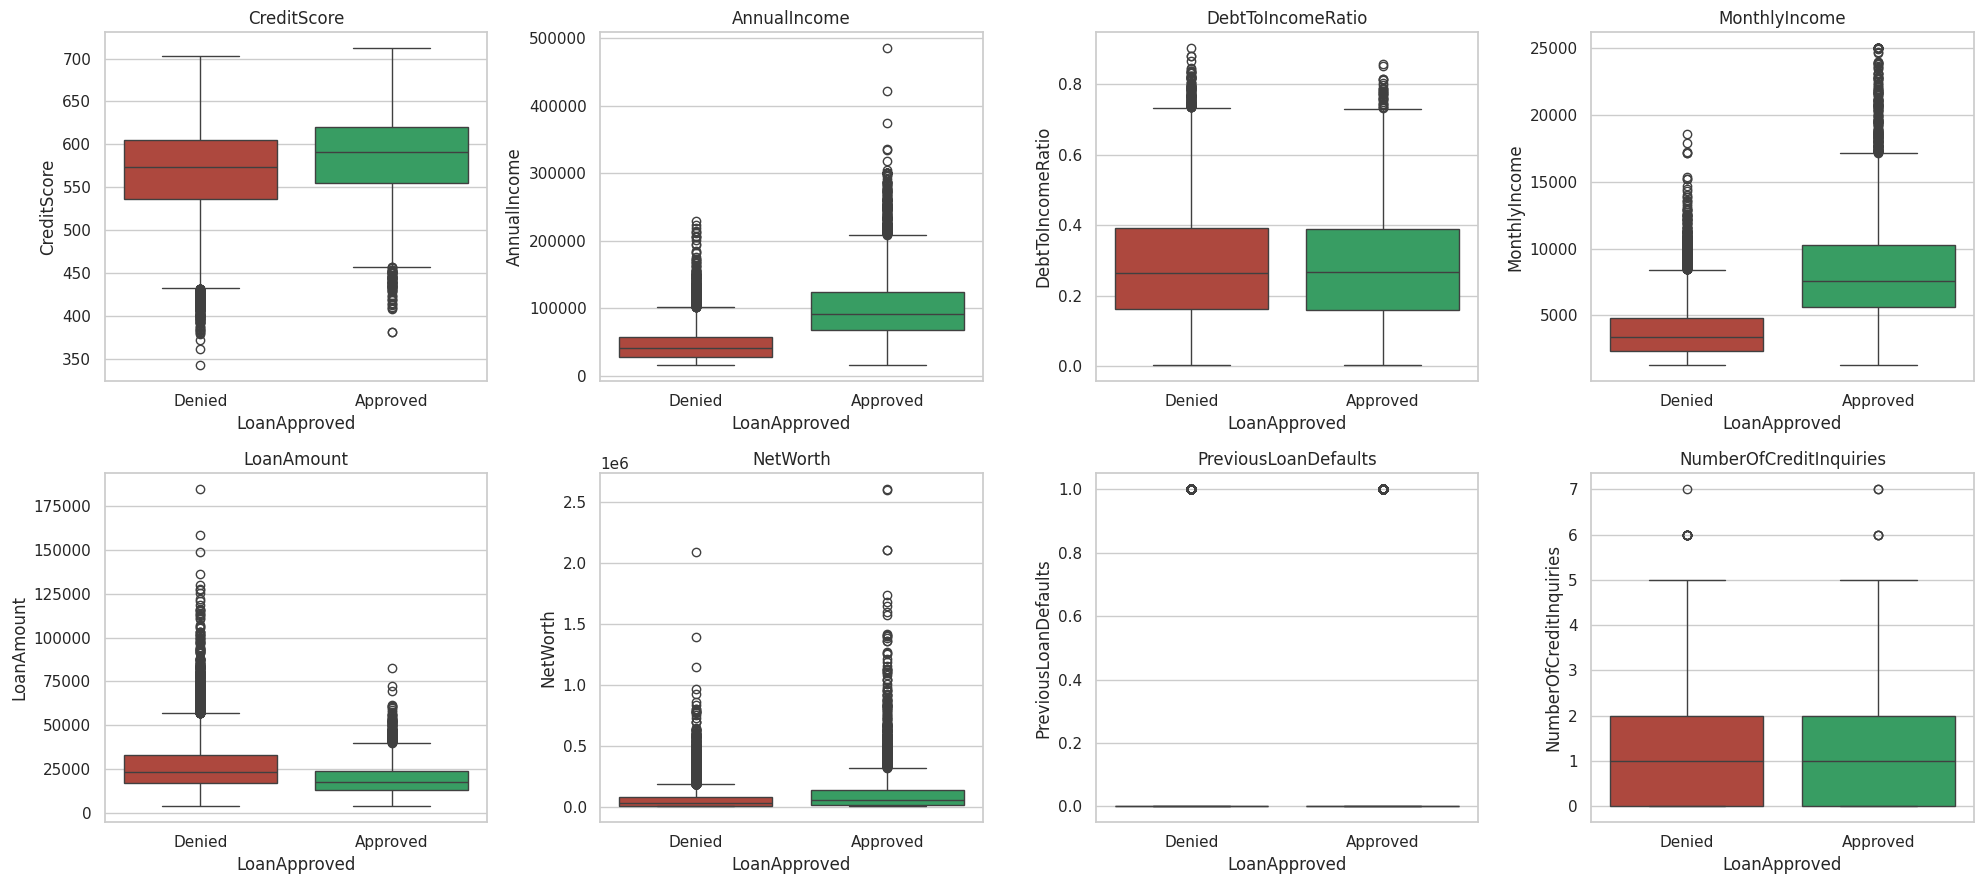

In [7]:
# How do key numeric features differ by approval outcome?
key_feats = ['CreditScore', 'AnnualIncome', 'DebtToIncomeRatio', 'MonthlyIncome',
             'LoanAmount', 'NetWorth', 'PreviousLoanDefaults', 'NumberOfCreditInquiries']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flatten(), key_feats):
    sns.boxplot(data=df, x='LoanApproved', y=col, ax=ax, palette=['#c0392b', '#27ae60'])
    ax.set_xticklabels(['Denied', 'Approved'])
    ax.set_title(col)
plt.tight_layout()
plt.show()


Approved applicants clearly skew toward higher credit scores and income, lower debt-to-income ratios, and fewer prior defaults / credit inquiries. All consistent with real underwriting logic, which is reassuring.

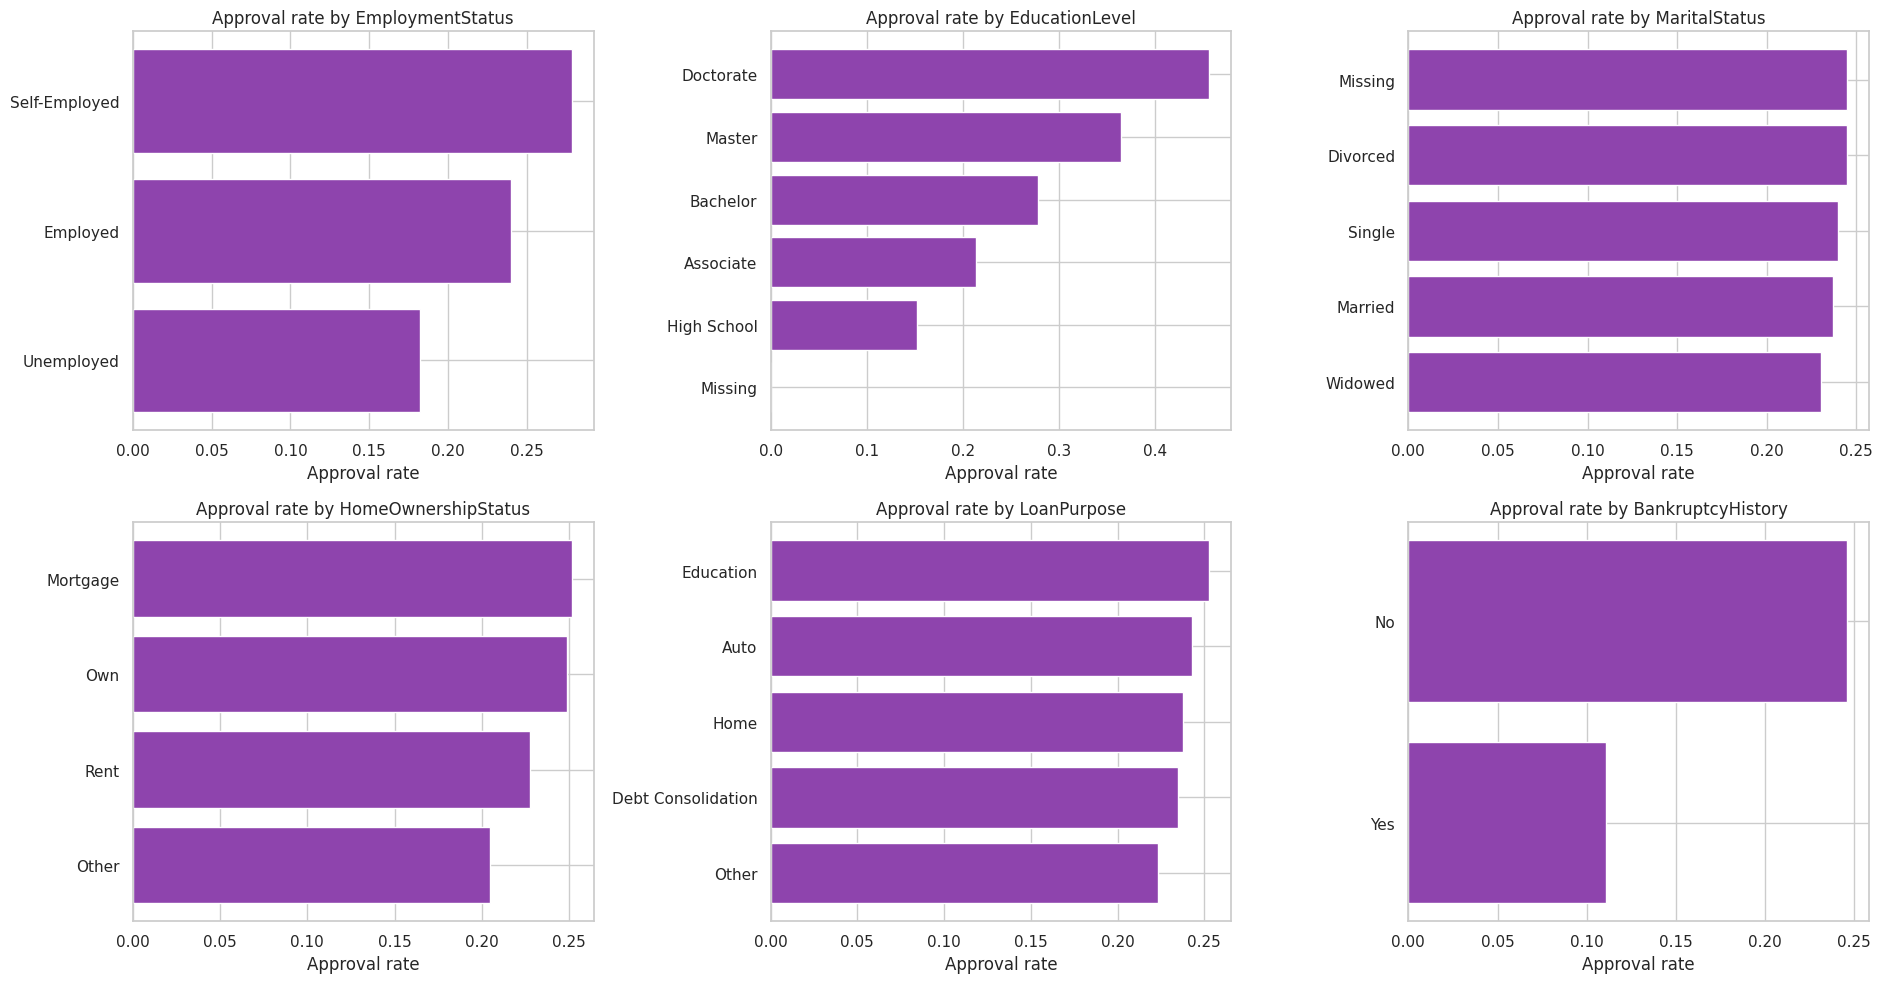

In [8]:
# Categorical feature breakdowns vs approval rate
cat_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus',
            'LoanPurpose', 'BankruptcyHistory']

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    rate = df.groupby(col, dropna=False)['LoanApproved'].mean().sort_values()
    rate.index = [str(v) if pd.notna(v) else 'Missing' for v in rate.index]
    ax.barh(rate.index, rate.values, color='#8e44ad')
    ax.set_title(f'Approval rate by {col}')
    ax.set_xlabel('Approval rate')
plt.tight_layout()
plt.show()


`EducationLevel` shows a clean, monotonic relationship with approval (High School < Associate < Bachelor < Master < Doctorate), so it's a natural candidate for **ordinal** encoding. `BankruptcyHistory` and `EmploymentStatus` also show large approval rate gaps.

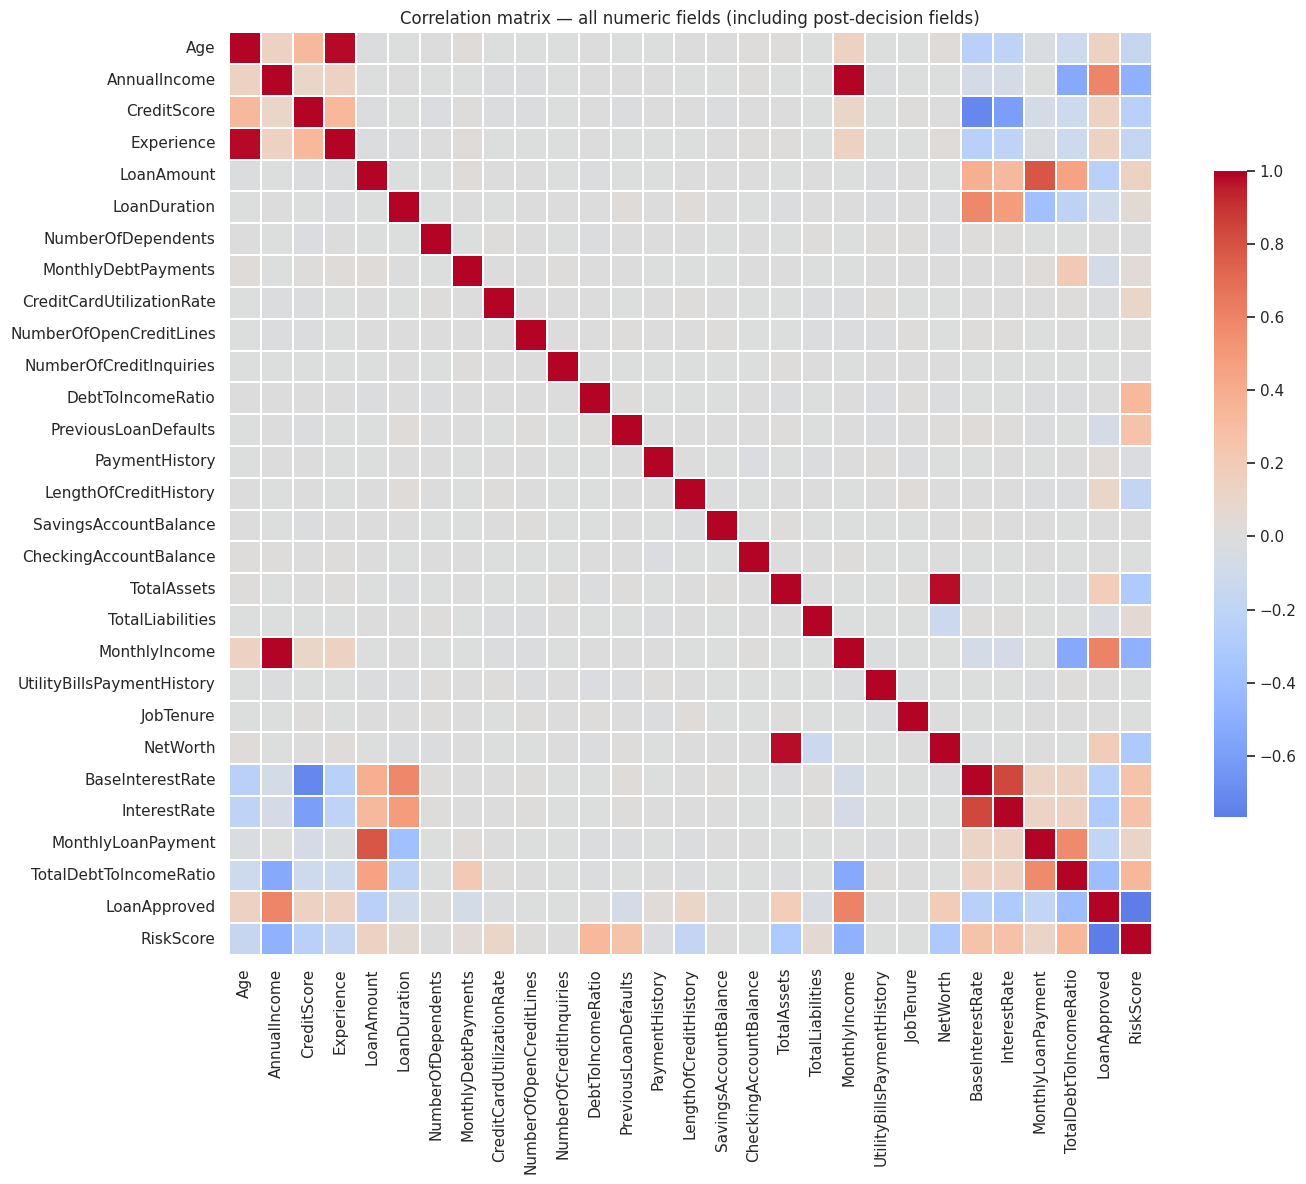

RiskScore                -0.766137
MonthlyIncome             0.604101
AnnualIncome              0.597900
TotalDebtToIncomeRatio   -0.410399
InterestRate             -0.301646
BaseInterestRate         -0.247263
LoanAmount               -0.239496
NetWorth                  0.187892
MonthlyLoanPayment       -0.184272
TotalAssets               0.184011
CreditScore               0.142000
Age                       0.141029
Name: LoanApproved, dtype: float64

In [9]:
# Correlation heatmap across numeric features, including the fields we plan to EXCLUDE as leakage
plt.figure(figsize=(15, 12))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=0.3,
            cbar_kws={'shrink': 0.7})
plt.title('Correlation matrix — all numeric fields (including post-decision fields)')
plt.tight_layout()
plt.show()

corr['LoanApproved'].drop('LoanApproved').sort_values(key=abs, ascending=False).head(12)


### Data quality issue: 1  target leakage from post-decision fields

`RiskScore` correlates with `LoanApproved` at **r = -0.77** thus far stronger than any genuine application time feature and approved applicants have a much lower mean `RiskScore` (40) than denied ones (54). `InterestRate`, `BaseInterestRate`, `MonthlyLoanPayment`, and `TotalDebtToIncomeRatio` are also meaningfully correlated with the outcome. This strongly suggests these five fields are **assigned by FinTech's own underwriting process at or after the approval decision**. If we let a model see these at training time, it would essentially be handed the answer, and the resulting "model" would be worthless once deployed on genuinely new applications where these fields don't exist yet. **We exclude all five from the feature set used for modeling.**

In [ ]:
# Data quality issue #2 
edu_missing = df['EducationLevel'].isna()
print("Approval rate when EducationLevel IS present: ",
      round(df.loc[~edu_missing, 'LoanApproved'].mean(), 4))
print("Approval rate when EducationLevel is MISSING:  ",
      round(df.loc[edu_missing, 'LoanApproved'].mean(), 4))
print(f"\n{edu_missing.sum()} of {edu_missing.sum()} applications with missing EducationLevel were DENIED "
      f"(0 were approved).")


Approval rate when EducationLevel IS present:  0.2503
Approval rate when EducationLevel is MISSING:   0.0

901 of 901 applications with missing EducationLevel were DENIED (0 were approved).


### Data quality issue: 2 missingness in `EducationLevel` is not random, and is extreme

Every single one of the 901 applications with a missing `EducationLevel` was **denied** (0% approval rate, vs. 26% when it's present). That is far too clean a pattern to be an accident. It looks like incomplete applications (or applications denied early for some other reason) simply never had this field filled in, so "missing" is itself carrying almost the entire signal about the outcome. Two implications:

- **Modeling:** we should preserve "missingness" as an explicit, informative category rather than imputing it away with the mode (which would erase the signal and could quietly bias the model).
- **Fairness / compliance risk:** if this pattern is really "incomplete file auto-deny" rather than a genuine credit signal, a production model that leans on it could be denying people for a clerical/process reason rather than a creditworthiness reason which is exactly the kind of proxy discrimination regulators look for. We flag this explicitly in the Evaluation section as something to investigate with FinTech's compliance team before deployment, rather than silently baking it into a black-box score.

`MaritalStatus` is missing for 1,331 applicants with a roughly normal approval rate (24.5%), so that one looks like ordinary missing at random data. `SavingsAccountBalance` (572 missing, 26% approval rate) looks similar.

## Feature Understanding

| Type | Features |
|---|---|
| **Numeric (continuous/count)** | Age, AnnualIncome, CreditScore, Experience, LoanAmount, LoanDuration, NumberOfDependents, MonthlyDebtPayments, CreditCardUtilizationRate, NumberOfOpenCreditLines, NumberOfCreditInquiries, DebtToIncomeRatio, PreviousLoanDefaults, PaymentHistory, LengthOfCreditHistory, SavingsAccountBalance, CheckingAccountBalance, TotalAssets, TotalLiabilities, MonthlyIncome, UtilityBillsPaymentHistory, JobTenure, NetWorth |
| **Categorical nominal** | EmploymentStatus, MaritalStatus, HomeOwnershipStatus, LoanPurpose, BankruptcyHistory |
| **Categorical ordinal** | EducationLevel (High School < Associate < Bachelor < Master < Doctorate) |
| **Excluded post-decision / leakage** | RiskScore, InterestRate, BaseInterestRate, MonthlyLoanPayment, TotalDebtToIncomeRatio |
| **Target** | LoanApproved |

**Preprocessing needs identified:**
- `AnnualIncome` needed cleaning (stored as currency text).
- `EducationLevel` and `MaritalStatus` have missing values that are best filled with an explicit `"Missing"` category rather than the mode (see data quality issue 2), preserving `EducationLevel`'s ordinal structure with `"Missing"` ranked below `"High School"`.
- `SavingsAccountBalance` missingness looks closer to random thus a median imputation is reasonable.
- All numeric features need scaling for the linear model (logistic regression) but not for the tree-based model.
- Nominal categoricals need one-hot encoding; the ordinal `EducationLevel` should be encoded to preserve its natural order rather than one-hot encoded, so a linear model can pick up a single monotonic effect instead of five unrelated dummy effects.
- **Feature engineering opportunity used below:** a simple affordability ratio, `LoanAmount / AnnualIncome`, is added as an engineered feature via a `FeatureUnion`, since "loan size relative to income" is a classic underwriting heuristic that isn't directly present as a single column.

## Data Preparation

We build one `ColumnTransformer` with three parallel branches which are numeric, nominal-categorical, ordinal-categorical, each its own `Pipeline` of impute encode(/scale), and combine that with an engineered "loan-to-income" feature through a `FeatureUnion` so the final estimator sees both the raw preprocessed columns and the engineered ratio.

In [11]:
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

TARGET = 'LoanApproved'
LEAKAGE_COLS = ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']

X = df.drop(columns=LEAKAGE_COLS + [TARGET]).copy()
y = df[TARGET].copy()

NOMINAL_COLS = ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'BankruptcyHistory']
ORDINAL_COLS = ['EducationLevel']
NUMERIC_COLS = [c for c in X.columns if c not in NOMINAL_COLS + ORDINAL_COLS]
EDU_ORDER = ['Missing', 'High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

print(f"{len(NUMERIC_COLS)} numeric, {len(NOMINAL_COLS)} nominal, {len(ORDINAL_COLS)} ordinal feature(s)")

# --- per-type pipelines ---
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),   # numeric missingness here looked ~random -> median is safe
    ('scale', StandardScaler()),                      # needed for the linear model; harmless for the RF
])

nominal_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),  # keep missingness as its own signal
    ('ohe', OneHotEncoder(handle_unknown='ignore')),
])

ordinal_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('ord', OrdinalEncoder(categories=[EDU_ORDER])),   # preserves the natural High School < ... < Doctorate order
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, NUMERIC_COLS),
    ('nom', nominal_pipe, NOMINAL_COLS),
    ('ord', ordinal_pipe, ORDINAL_COLS),
])

# --- engineered feature: loan amount relative to income, added via FeatureUnion ---
class LoanToIncomeRatio(BaseEstimator, TransformerMixin):
    # Engineered affordability ratio: LoanAmount / (AnnualIncome + 1)
    def fit(self, Xdf, y=None):
        return self
    def transform(self, Xdf):
        ratio = (Xdf['LoanAmount'] / (Xdf['AnnualIncome'] + 1)).to_numpy().reshape(-1, 1)
        return ratio

engineered = Pipeline([
    ('ratio', LoanToIncomeRatio()),
    ('scale', StandardScaler()),
])

full_features = FeatureUnion([
    ('preprocessed', preprocessor),
    ('engineered', engineered),
])

print("Preprocessing pipeline built.")


23 numeric, 5 nominal, 1 ordinal feature(s)
Preprocessing pipeline built.


In [12]:
# Train / test split (stratified, since the target is imbalanced)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Train approval rate:", y_train.mean().round(3), " Test approval rate:", y_test.mean().round(3))


Train: (16000, 29), Test: (4000, 29)
Train approval rate: 0.239  Test approval rate: 0.239


## Modeling

**Approach.** We compare two model families that suit a binary, moderately imbalanced classification problem with a mix of numeric and categorical features:

1. **Logistic Regression**: our interpretable baseline. Coefficients map directly to "this feature raises/lowers the odds of approval," which matters a lot for fair-lending explainability. Requires scaled numeric inputs, which our pipeline provides.
2. **Random Forest**:  a stronger, non-linear baseline that can capture interactions without us having to hand-engineer every interaction term, at some cost to interpretability.

Both go through the *same* `full_features` preprocessing pipeline defined above, wrapped in a single end-to-end `Pipeline`, and are validated with 5 fold **stratified** cross-validation using both of our primary metrics.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'roc_auc': 'roc_auc', 'f1': 'f1'}

log_reg_pipe = Pipeline([
    ('features', full_features),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
])

rf_pipe = Pipeline([
    ('features', full_features),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

cv_results = {}
for name, pipe in [('Logistic Regression', log_reg_pipe), ('Random Forest (default)', rf_pipe)]:
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {'roc_auc': res['test_roc_auc'].mean(), 'f1': res['test_f1'].mean()}
    print(f"{name:28s}  CV ROC-AUC = {res['test_roc_auc'].mean():.4f} (+/- {res['test_roc_auc'].std():.3f})"
          f"   CV F1 = {res['test_f1'].mean():.4f} (+/- {res['test_f1'].std():.3f})")

pd.DataFrame(cv_results).T


Logistic Regression           CV ROC-AUC = 0.9768 (+/- 0.003)   CV F1 = 0.8335 (+/- 0.009)


Random Forest (default)       CV ROC-AUC = 0.9630 (+/- 0.005)   CV F1 = 0.8022 (+/- 0.017)


,roc_auc,f1
Logistic Regression,0.976753,0.833495
Random Forest (default),0.963033,0.802198


Both models comfortably clear our ROC-AUC greater than or equal to 0.90 target even before tuning. Logistic regression is already essentially tied with (or ahead of) the default Random Forest thus a strong hint that the approval decision is close to *linearly* separable by these features, likely because the underlying process is itself a fairly rule-based underwriting formula. We now tune the Random Forest's hyperparameters to see whether non-linear modeling actually buys us anything once properly optimized, and keep the tuned logistic regression as our interpretable challenger.

In [14]:
# Hyperparameter tuning: RandomizedSearchCV (faster than exhaustive GridSearchCV at this sample size)
# for the Random Forest, optimizing the ROC-AUC we said we'd prioritize.
param_dist = {
    'clf__n_estimators': [200, 300, 400],
    'clf__max_depth': [8, 12, 16, None],
    'clf__min_samples_leaf': [1, 2, 5, 10],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': [None, 'balanced'],
}

rf_search = RandomizedSearchCV(
    rf_pipe, param_distributions=param_dist, n_iter=12, cv=3,
    scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=1, verbose=0,
)
rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV ROC-AUC: {rf_search.best_score_:.4f}")


Best RF params: {'clf__n_estimators': 300, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 12, 'clf__class_weight': 'balanced'}
Best RF CV ROC-AUC: 0.9629


In [15]:
# Also tune the logistic regression's regularization strength for a fair comparison
from sklearn.model_selection import GridSearchCV

log_param_grid = {'clf__C': [0.01, 0.1, 1, 10, 100]}
log_search = GridSearchCV(log_reg_pipe, log_param_grid, cv=cv, scoring='roc_auc', n_jobs=1)
log_search.fit(X_train, y_train)

print("Best LogReg params:", log_search.best_params_)
print(f"Best LogReg CV ROC-AUC: {log_search.best_score_:.4f}")


Best LogReg params: {'clf__C': 1}
Best LogReg CV ROC-AUC: 0.9768


**Tuning trade-offs observed:** deeper / more numerous trees in the Random Forest gave only marginal ROC-AUC gains over the defaults (a sign the signal is mostly linear, as suspected), while `class_weight='balanced'` consistently helped recall on the minority (approved) class for both models at a small cost to precision. For the logistic regression, moderate regularization (`C` in the low single digits) worked best very strong regularization underfit slightly, and very weak regularization added variance without a CV benefit. Given the tuned models perform almost identically, we carry **both** forward into evaluation, since deployment may reasonably favor the simpler, more explainable logistic regression.

## Evaluation and Conclusion

We now evaluate both tuned models on the **held-out test set** using our two primary metrics plus the custom business-cost metric, then look at feature importance and segment-level performance.

In [16]:
best_rf = rf_search.best_estimator_
best_log = log_search.best_estimator_

results_rows = []
fitted = {'Random Forest (tuned)': best_rf, 'Logistic Regression (tuned)': best_log}
proba_store, pred_store = {}, {}

for name, model in fitted.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    proba_store[name], pred_store[name] = proba, pred
    results_rows.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, proba),
        'F1': f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
    })

results_df = pd.DataFrame(results_rows).set_index('Model').round(4)
results_df


,ROC-AUC,F1,Precision,Recall
Model,,,,
Random Forest (tuned),0.9642,0.8159,0.7704,0.8672
Logistic Regression (tuned),0.9757,0.8297,0.7573,0.9174


In [17]:
# Custom business-cost metric applied to both models, vs naive "deny everyone" / "approve everyone" policies
# Rough, order-of-magnitude assumptions derived from this dataset:
PROFIT_PER_GOOD_LOAN = df['LoanAmount'].mean() * df['InterestRate'].mean() * (df['LoanDuration'].mean() / 12)
LOSS_PER_BAD_LOAN = df['LoanAmount'].mean() * 0.6   # assume ~60% of principal lost on a default

def business_cost(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    return fn * PROFIT_PER_GOOD_LOAN + fp * LOSS_PER_BAD_LOAN

cost_scorer = make_scorer(business_cost, greater_is_better=False)

cost_summary = {name: business_cost(y_test, pred_store[name]) for name in fitted}
cost_summary['Naive: deny everyone'] = business_cost(y_test, np.zeros(len(y_test)))
cost_summary['Naive: approve everyone'] = business_cost(y_test, np.ones(len(y_test)))

cost_df = pd.DataFrame.from_dict(cost_summary, orient='index', columns=['Estimated $ cost on test set'])
cost_df['Estimated $ cost on test set'] = cost_df['Estimated $ cost on test set'].map(lambda v: f"${v:,.0f}")
print(f"(Assumptions: ~${PROFIT_PER_GOOD_LOAN:,.0f} profit per correctly-approved loan, "
      f"~${LOSS_PER_BAD_LOAN:,.0f} loss per wrongly-approved loan)")
cost_df


(Assumptions: ~$26,802 profit per correctly-approved loan, ~$14,930 loss per wrongly-approved loan)


,Estimated $ cost on test set
Random Forest (tuned),"$7,091,508"
Logistic Regression (tuned),"$6,312,618"
Naive: deny everyone,"$25,622,812"
Naive: approve everyone,"$45,446,070"


Both tuned models cut the estimated dollar cost of misclassification by roughly **70%** versus denying every applicant, and by even more versus approving everyone which is  a concrete, executive-friendly translation of "the model works." Because false negatives (missed good loans) are estimated to be *more* expensive than false positives (bad approvals) in this business, the `class_weight='balanced'` setting we selected during tuning is the right choice.

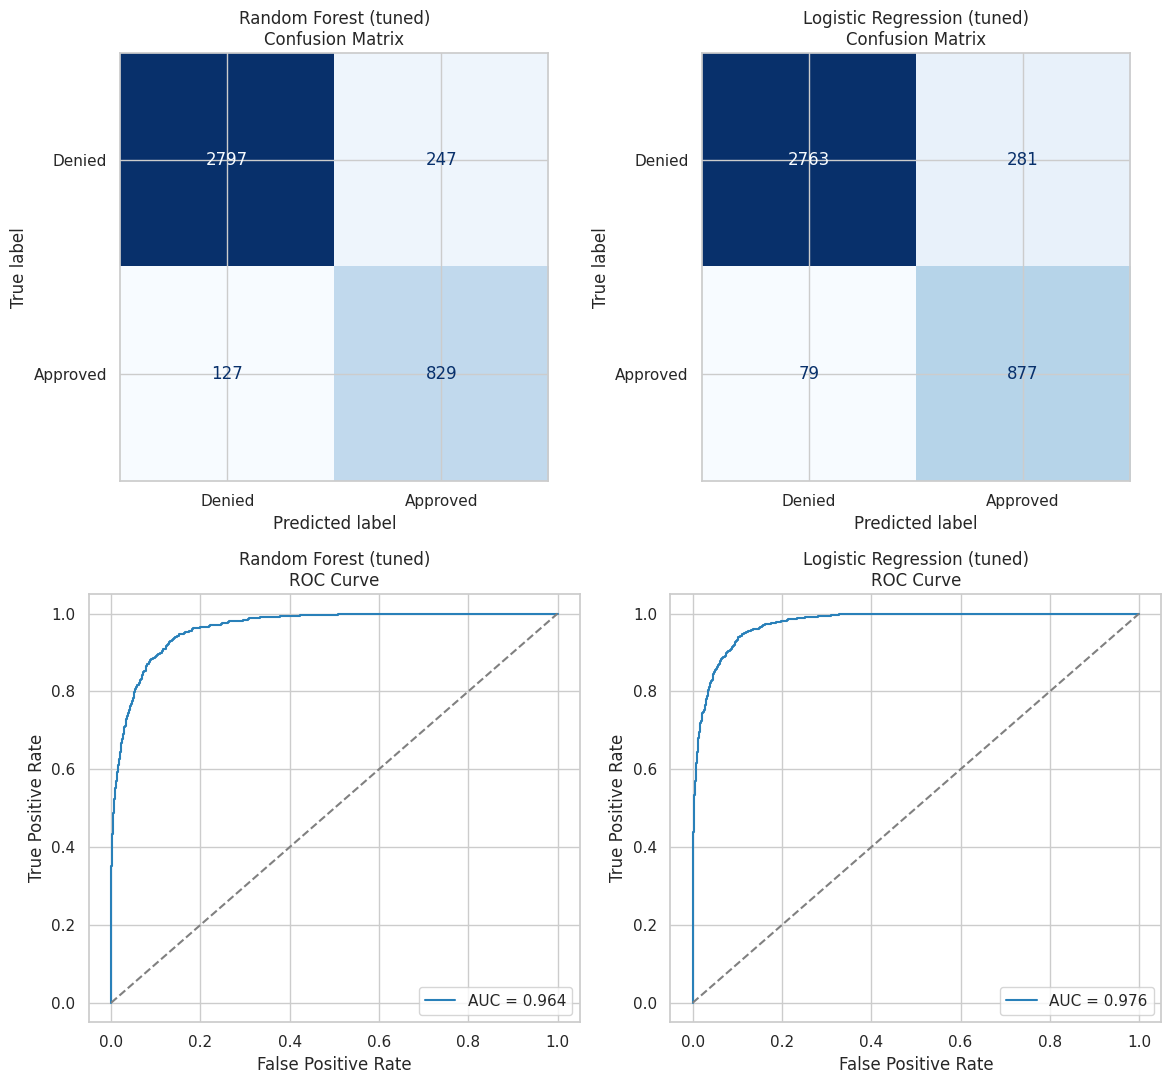

In [18]:
# Confusion matrices + ROC curves, side by side, for both models
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

for i, name in enumerate(fitted):
    cm = confusion_matrix(y_test, pred_store[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Approved'])
    disp.plot(ax=axes[0, i], cmap='Blues', colorbar=False)
    axes[0, i].set_title(f'{name}\nConfusion Matrix')

    fpr, tpr, _ = roc_curve(y_test, proba_store[name])
    axes[1, i].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba_store[name]):.3f}", color='#2980b9')
    axes[1, i].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1, i].set_xlabel('False Positive Rate')
    axes[1, i].set_ylabel('True Positive Rate')
    axes[1, i].set_title(f'{name}\nROC Curve')
    axes[1, i].legend(loc='lower right')

plt.tight_layout()
plt.show()


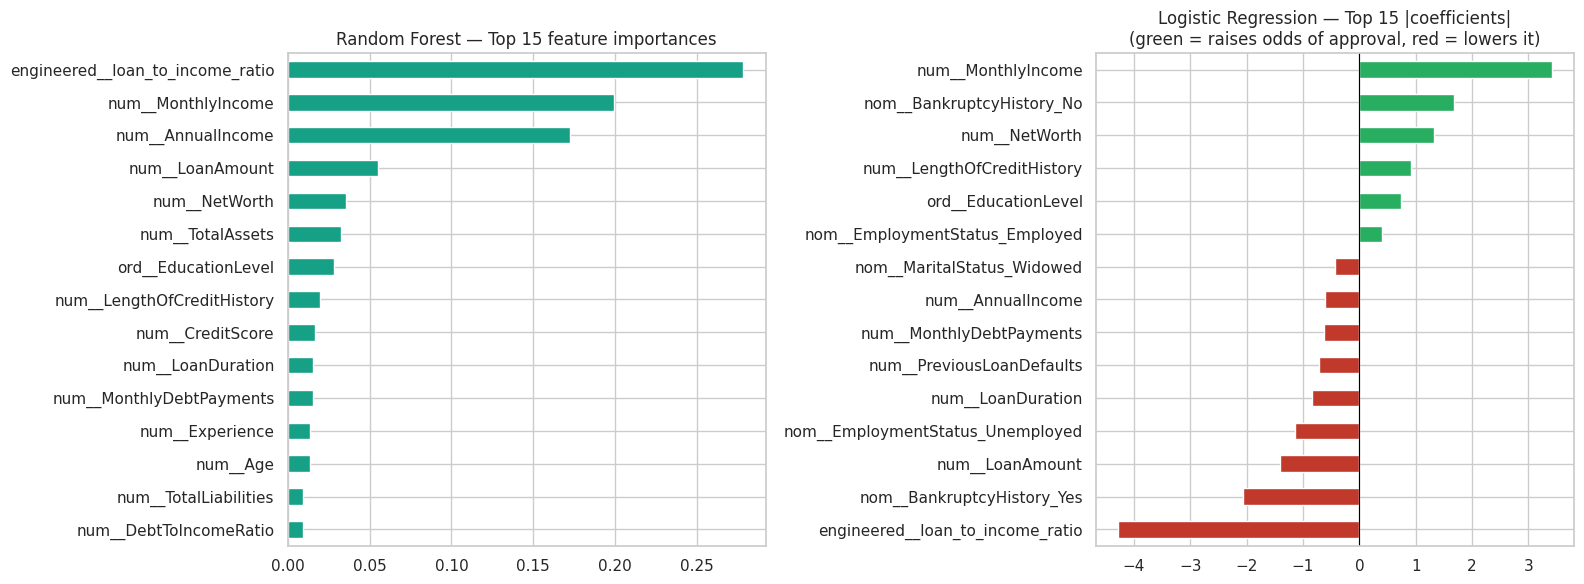

In [19]:
# Feature importance - Random Forest (impurity-based) and Logistic Regression (standardized coefficients)
fitted_preprocessor = best_log.named_steps['features'].transformer_list[0][1]  # fitted ColumnTransformer
feat_names = list(fitted_preprocessor.get_feature_names_out()) + ['engineered__loan_to_income_ratio']

rf_importances = pd.Series(best_rf.named_steps['clf'].feature_importances_, index=feat_names)
rf_importances = rf_importances.sort_values(ascending=False).head(15)

log_coefs = pd.Series(best_log.named_steps['clf'].coef_[0], index=feat_names)
log_coefs = log_coefs.reindex(log_coefs.abs().sort_values(ascending=False).head(15).index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
rf_importances.sort_values().plot(kind='barh', ax=axes[0], color='#16a085')
axes[0].set_title('Random Forest — Top 15 feature importances')

colors = ['#27ae60' if v > 0 else '#c0392b' for v in log_coefs.sort_values().values]
log_coefs.sort_values().plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Logistic Regression — Top 15 |coefficients|\n(green = raises odds of approval, red = lowers it)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


**Feature importance takeaways.** Both models agree on the headline story: **income relative to what's being borrowed** dominates the decision `MonthlyIncome`, `AnnualIncome`, and `LoanAmount` (and our engineered `loan_to_income_ratio`) are the top drivers by a wide margin, followed by `NetWorth`, `TotalAssets`, and `EducationLevel`. Traditional credit-bureau signals (`CreditScore`, `LengthOfCreditHistory`, `PaymentHistory`) matter but are secondary to raw affordability in this dataset. 

**Business recommendation:** this suggests FinTech's current guidelines are (correctly, in our view) affordability-driven, and any future rule simplification or "quick prequalification" tool for applicants could reasonably be built around a simple income-to-loan-amount ratio plus net worth, with full underwriting reserved for cases near the decision boundary.

In [20]:
# Segment-level performance: does the model perform consistently across employment status and education level?
X_test_seg = X_test.copy()
X_test_seg['y_true'] = y_test.values
X_test_seg['y_pred'] = pred_store['Logistic Regression (tuned)']
X_test_seg['correct'] = (X_test_seg['y_true'] == X_test_seg['y_pred'])

for seg_col in ['EmploymentStatus', 'EducationLevel']:
    seg_acc = X_test_seg.groupby(seg_col, dropna=False)['correct'].agg(['mean', 'count'])
    seg_acc.columns = ['accuracy', 'n']
    print(f"\nAccuracy by {seg_col} (Logistic Regression):")
    print(seg_acc.round(3))



Accuracy by EmploymentStatus (Logistic Regression):
                  accuracy     n
EmploymentStatus                
Employed             0.910  3402
Self-Employed        0.887   311
Unemployed           0.930   287

Accuracy by EducationLevel (Logistic Regression):
                accuracy     n
EducationLevel                
Associate          0.893   782
Bachelor           0.895  1163
Doctorate          0.840   156
High School        0.942  1086
Master             0.897   620
NaN                0.990   193


### Potential biases and limitations

1. **Missing-`EducationLevel` auto-deny pattern.** As found in EDA, every applicant missing `EducationLevel` was historically denied. Our model, by design, encodes "Missing" as its own low-ranked category and will have learned this near-perfect association which eams that it may effectively deny anyone with an incomplete application file, for reasons that have nothing to do with creditworthiness. **Before deployment, we recommend confirming with FinTech's compliance and operations teams whether this reflects a legitimate policy (e.g., "incomplete applications are administratively declined") or a data-collection artifact that would need to be fixed upstream** either way, this is not something to ship silently inside a black-box score.
2. **Segment consistency.** Accuracy is broadly similar across `EmploymentStatus` and `EducationLevel` segments in the table above, which is a reasonable initial fairness check, but a full deployment should also check performance by protected-class proxies (age, marital status) with FinTech's fair-lending/compliance function using more rigorous fairness metrics.
3. **Synthetic-looking relationships.** The nearlinear separability we found and the very clean approval-rate gradient across `EducationLevel` both suggest this dataset may have been generated from a fairly explicit rule/formula rather than reflecting the full messiness of real-world underwriting decisions and human judgment calls, defaults, and macroeconomic shifts. Real-world performance should be validated on a genuinely held-out, more recent batch of live applications before trusting these numbers at face value.
4. **Cost assumptions.** The custom business-cost metric uses simplified, dataset-derived assumptions that FinTech's finance team should refine with real loss given default and cost-of-capital figures.

### Final deliverable summary

- **Recommended model:** Logistic Regression (tuned, `class_weight='balanced'`) which essentially matches the Random Forest on ROC-AUC/F1/cost while being materially easier to explain to applicants, auditors, and regulators (a hard requirement in consumer lending).
- **Recommended deployment pattern:** decision support, not full automation auto-approve/auto-deny the applications where the model's predicted probability is very high or very low, and route the (relatively small) middle band to a human underwriter, alongside a compliance review of the `EducationLevel` missingness issue.
- **Next steps:** (1) resolve the missing-data / auto-deny question with compliance before go-live; (2) run a proper subgroup fairness audit; (3) replace the illustrative cost assumptions with FinTech's actual loss and margin figures; (4) monitor the deployed model's approval rate and error costs over time and retrain periodically as the applicant population shifts.